# 01. Classical Computational Limits in Astrobiological Inference
### Master's Thesis: Quantum Bayesian Inference for Atmospheric Biosignature and Technosignature Characterization in Exoplanetary Systems
**Author:** Daniel Rivero Losa  
**Tutor:** Roberto Campos Ortiz  
**Institution:** Universidad Antonio de Nebrija — Escuela Politécnica Superior  
**Reference Section:** Chapter 2 and Section 4.2 of the Thesis Manuscript  

---
### 📌 Executive Summary of the Deliverable
This notebook constitutes the **classical reference benchmark** for the Master's Thesis. Its core objective is to quantitatively and empirically demonstrate the insurmountable computational bottlenecks of classical exact and stochastic inference algorithms when evaluating ultra-rare astrobiological anomalies in exoplanetary atmospheres, specifically focused on the warm sub-Neptune / Hycean candidate **K2-18b** observed by the James Webb Space Telescope (JWST).

In particular, this benchmark demonstrates:
1. **The Treewidth Ceiling in Exact Classical Inference (`pgmpy`):** The spatial and temporal complexity $\mathcal{O}(N \cdot d^{w+1})$ of the **Junction Tree Algorithm (JTA)** and **Variable Elimination (VE)**, proving that dense feedback graphs rapidly saturate classical memory.
2. **L'Ecuyer et al. (2010) Theorem (Relative Error Divergence):** The asymptotic divergence of the Relative Error ($RE \to \infty$) when the target hypothesis probability decreases towards zero ($p = 10^{-6}$, corresponding to an industrial chlorofluorocarbon technosignature, CFCs).
3. **The Classical Asymptotic Barrier $\mathcal{O}(M^{-1/2})$:** The standard Monte Carlo convergence rate that imposes an intractable quadratic penalty (complexity $\mathcal{O}(\epsilon^{-2})$) to gain each order of magnitude in precision.
4. **The MCMC Mode Entrapment (*Rare-State Trap*):** The collapse of effective sample size and Kac's Recurrence Theorem, where a discrete Metropolis-Hastings Markov chain requires $\sim 10^6$ iterations before its first visit to the anomaly.
5. **The Quantum Advantage Crossover Point:** Rigorous comparison against Quantum Amplitude Estimation (QAE), whose Heisenberg limit $\mathcal{O}(M_q^{-1})$ reduces the query complexity to $\mathcal{O}(\epsilon^{-1})$, justifying the quantum transition developed in Chapter 4.

## 1. Theoretical Framework: Variance Divergence, Treewidth Limits, and L'Ecuyer's Theorem

### 1.1 Bayesian Inference of Rare Events in Astrobiology
In exoplanetary characterization, the atmospheric and astrophysical parameters of a planet are formalized as a joint probabilistic state over $N$ discrete random variables:
$$\mathbf{X} = \{X_0, X_1, \dots, X_{N-1}\}$$
where $X_8$ represents an industrial technosignature gas ($\text{CFCs}$). In observational missions, spectroscopic data gathered by space telescopes (e.g., JWST transit transmission spectra of K2-18b) are injected into the causal network as evidence $\mathbf{E} = \mathbf{e}$ (e.g., detection of $\mathrm{CH}_4$, $\mathrm{CO}_2$, and habitable orbital irradiance). The posterior probability of the latent hypothesis is governed by Bayes' Theorem:
$$P(X_8 = 1 \mid \mathbf{E} = \mathbf{e}) = \frac{P(X_8 = 1, \mathbf{e})}{P(\mathbf{e})} = \frac{\sum_{\mathbf{x} \setminus \{X_8, \mathbf{E}\}} P(\mathbf{x}, X_8=1, \mathbf{e})}{\sum_{\mathbf{x} \setminus \mathbf{E}} P(\mathbf{x}, \mathbf{e})}$$

Because an industrial technosignature is an ultra-rare prior event ($p = P(X_8 = 1) \approx 10^{-6}$), classical algorithms face severe mathematical obstacles in resolving this posterior.

### 1.2 Exact Inference: Junction Tree and the Treewidth Ceiling
Classical exact inference marginalizes unobserved nuisance parameters by compiling the Directed Acyclic Graph (DAG) into a secondary clique tree via the **Junction Tree Algorithm (JTA)**. The exact spatial and temporal complexity is strictly governed by the **treewidth** ($w$) of the moralized, triangulated graph:
$$\mathcal{C}_{\text{exact}} = \mathcal{O}\left(N \cdot d^{w+1}\right)$$
where $d$ is the variable cardinality ($d=2$ for binary nodes). While sparse graphs maintain a low treewidth ($w=2$), photochemical atmospheric networks contain dense cyclic reaction loops (hydroxyl catalytic cycles, photolysis, volcanism). During graph moralization, marrying parents across dense loops forces $w \to N - 1$, causing an exponential memory explosion $\mathcal{O}(d^N)$ that exhausts physical RAM. Cooper (1990) proved that exact inference in Bayesian belief networks is NP-hard.

### 1.3 Stochastic Sampling and the Theorem of L'Ecuyer et al. (2010)
To avoid the spatial explosion of exact inference, classical retrieval pipelines resort to stochastic Monte Carlo sampling. Let $Y_i \in \{0, 1\}$ be the Bernoulli indicator variable for $X_8 = 1$, with expectation $\mathbb{E}[Y_i] = p$. The standard Monte Carlo estimator over $M$ independent and identically distributed (i.i.d.) samples is:
$$\hat{p}_M = \frac{1}{M} \sum_{i=1}^M Y_i, \quad \mathbb{E}[\hat{p}_M] = p, \quad \text{Var}(\hat{p}_M) = \frac{p(1-p)}{M}$$

Evaluating rare phenomena in observational astrobiology depends fundamentally on the **Relative Error** ($RE$, coefficient of variation):
$$RE(\hat{p}_M) \equiv \frac{\sigma(\hat{p}_M)}{\mathbb{E}[\hat{p}_M]} = \frac{\sqrt{\frac{p(1-p)}{M}}}{p} = \sqrt{\frac{1-p}{M \cdot p}}$$

When the target hypothesis is rare ($p \ll 1$):
$$RE(\hat{p}_M) \approx \frac{1}{\sqrt{M \cdot p}}$$

> **Theorem (L'Ecuyer et al., 2010 — Relative Error Divergence):**  
> For any finite classical sample size $M$, as the prior probability of the target phenomenon tends to zero:
> $$\lim_{p \to 0} RE(\hat{p}_M) = \lim_{p \to 0} \frac{1}{\sqrt{M \cdot p}} = \infty$$
> To ensure that the relative error remains bounded below an admissible threshold $\epsilon_{\text{rel}}$ (e.g., $\epsilon_{\text{rel}} = 0.05$ for a 5% relative uncertainty window), the required classical sample size scales as:
> $$M \ge \frac{1-p}{\epsilon_{\text{rel}}^2 \cdot p} = \mathcal{O}\left(\frac{1}{\epsilon_{\text{rel}}^2 \cdot p}\right)$$
> For $p = 10^{-6}$ and $\epsilon_{\text{rel}} = 0.05$, the classical simulator must generate at least $M \approx 4 \times 10^8$ complete planetary realizations.

### 1.4 Asymptotic Comparison: Classical vs. Quantum Amplitude Estimation (QAE)
- **Classical Monte Carlo / MCMC:** Sample complexity scales as $M_{\text{classical}} = \mathcal{O}\left(\frac{1}{\epsilon^2 \cdot p}\right)$.
- **Quantum QAE (Heisenberg Limit):** Combines Grover's amplitude amplification with Quantum Phase Estimation (QPE) and Inverse Quantum Fourier Transform (IQFT), achieving deterministic quadratic acceleration:
$$\epsilon_{\text{QAE}} = \mathcal{O}\left(\frac{1}{M_q}\right) \implies M_q = \mathcal{O}\left(\frac{1}{\epsilon \sqrt{p}}\right)$$
For $p = 10^{-6}$, the number of coherent oracle queries collapses from $\sim 10^8$ to $M_q \sim 10^3$, establishing the mathematical justification for the quantum pipeline.

In [1]:
import os
import sys
import time
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Classical Bayesian & Graphical Model Framework
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='pgmpy')
import pgmpy
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import networkx as nx

os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl_cache')
np.random.seed(42)

# Publication styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
    'figure.dpi': 150
})

print("✓ Classical computing environment initialized successfully.")
print(f"✓ Python version : {sys.version.split()[0]}")
print(f"✓ NumPy version  : {np.__version__}")
print(f"✓ SciPy version  : {stats.__name__}")
print(f"✓ pgmpy version  : {pgmpy.__version__}")

✓ Classical computing environment initialized successfully.
✓ Python version : 3.14.3
✓ NumPy version  : 2.5.2
✓ SciPy version  : scipy.stats
✓ pgmpy version  : 1.1.2


## 2. Exact Inference Baseline in `pgmpy`: Moralization, Triangulation, and Treewidth Limit

To evaluate the classical exact inference baseline formalized in **Section 2.2 of the Thesis**, we construct the 9-node DAG representing the astrophysical and geochemical parameters of **K2-18b** using `pgmpy`:

1. $X_0$ (**Stellar_M_Dwarf**): Spectral type of host star ($1 = \text{M-dwarf}, 0 = \text{other}$). Prior $P(X_0 = 1) = 0.75$.
2. $X_1$ (**Orbital_HZ**): Location in circumstellar liquid water Habitable Zone. Prior $P(X_1 = 1) = 0.20$.
3. $X_2$ (**Hycean_Planet**): Sub-Neptune planet with a massive global ocean and $\mathrm{H}_2$-rich envelope. Conditioned on $X_0$ and $X_1$.
4. $X_3$ (**Biological_Ocean**): Active marine biosphere. Conditioned on $X_2$.
5. $X_4$ (**Spectro_CH4**): Spectroscopic detection of methane ($\mathrm{CH}_4$). Conditioned on $X_2$.
6. $X_5$ (**Spectro_CO2**): Spectroscopic detection of carbon dioxide ($\mathrm{CO}_2$). Conditioned on $X_2$.
7. $X_6$ (**Spectro_H2O**): Spectroscopic detection of water vapor ($\mathrm{H}_2\mathrm{O}$). Conditioned on $X_1$.
8. $X_7$ (**Bio_DMS**): Volatile dimethyl sulfide biomarker. Conditioned on $X_3$.
9. $X_8$ (**Techno_CFC**): Industrial chlorofluorocarbons technosignature ($p_{\text{CFC}} = 1.0 \times 10^{-6}$). Strongly conditioned on an active marine biosphere ($X_3 = 1$).

We compile the model, compute its moralized and triangulated graph, extract maximal cliques, calculate the exact treewidth $w$, and execute **Variable Elimination** under JWST evidence:
$$\mathbf{e} = \{X_1 = 1 \text{ (Habitable Zone)}, X_4 = 1 \text{ (}\mathrm{CH}_4\text{)}, X_5 = 1 \text{ (}\mathrm{CO}_2\text{)}\}$$

In [2]:
# 1. Instantiate the Discrete Bayesian Network topology
k218b_dag = DiscreteBayesianNetwork([
    ('X0_Stellar_M', 'X2_Hycean'),
    ('X1_Orbit_HZ',  'X2_Hycean'),
    ('X2_Hycean',    'X3_Bio_Ocean'),
    ('X2_Hycean',    'X4_CH4'),
    ('X2_Hycean',    'X5_CO2'),
    ('X1_Orbit_HZ',  'X6_H2O'),
    ('X3_Bio_Ocean', 'X7_DMS'),
    ('X3_Bio_Ocean', 'X8_CFC')
])

# 2. Define formal Tabular Conditional Probability Distributions (CPDs)
# Root priors (Madhusudhan et al. 2023)
cpd_x0 = TabularCPD('X0_Stellar_M', 2, [[0.25], [0.75]])
cpd_x1 = TabularCPD('X1_Orbit_HZ',  2, [[0.80], [0.20]])

# X2: Hycean Condition conditioned on X0 and X1
# pgmpy evidence ordering: (X0=0, X1=0), (X0=0, X1=1), (X0=1, X1=0), (X0=1, X1=1)
cpd_x2 = TabularCPD('X2_Hycean', 2,
    [[0.95, 0.95, 0.95, 0.15],
     [0.05, 0.05, 0.05, 0.85]],
    evidence=['X0_Stellar_M', 'X1_Orbit_HZ'],
    evidence_card=[2, 2]
)

# X3: Marine Biosphere conditioned on Hycean state X2
cpd_x3 = TabularCPD('X3_Bio_Ocean', 2,
    [[0.99, 0.60],
     [0.01, 0.40]],
    evidence=['X2_Hycean'],
    evidence_card=[2]
)

# Atmospheric spectroscopic indicators
cpd_x4 = TabularCPD('X4_CH4', 2,
    [[0.85, 0.10],
     [0.15, 0.90]],
    evidence=['X2_Hycean'],
    evidence_card=[2]
)

cpd_x5 = TabularCPD('X5_CO2', 2,
    [[0.80, 0.20],
     [0.20, 0.80]],
    evidence=['X2_Hycean'],
    evidence_card=[2]
)

cpd_x6 = TabularCPD('X6_H2O', 2,
    [[0.90, 0.30],
     [0.10, 0.70]],
    evidence=['X1_Orbit_HZ'],
    evidence_card=[2]
)

cpd_x7 = TabularCPD('X7_DMS', 2,
    [[0.9999, 0.95],
     [0.0001, 0.05]],
    evidence=['X3_Bio_Ocean'],
    evidence_card=[2]
)

# Exact normalization for X8:
# Analytically: P(X3=1) = 0.0763. To enforce prior P(X8=1) = 1.0000e-6 strictly:
# P(X8=1 | X3=1) = 1.0e-6 / 0.0763 = 1.310616e-5
p_cfc_given_bio = 1.0e-6 / 0.0763
cpd_x8 = TabularCPD('X8_CFC', 2,
    [[1.0, 1.0 - p_cfc_given_bio],
     [0.0, p_cfc_given_bio]],
    evidence=['X3_Bio_Ocean'],
    evidence_card=[2]
)

k218b_dag.add_cpds(cpd_x0, cpd_x1, cpd_x2, cpd_x3, cpd_x4, cpd_x5, cpd_x6, cpd_x7, cpd_x8)
assert k218b_dag.check_model(), "Error: DAG specification is mathematically invalid."

# 3. Graph Moralization, Triangulation, and Treewidth Analysis
moral_graph = k218b_dag.to_undirected()
for node in k218b_dag.nodes():
    parents = list(k218b_dag.predecessors(node))
    for i in range(len(parents)):
        for j in range(i + 1, len(parents)):
            moral_graph.add_edge(parents[i], parents[j])

maximal_cliques = list(nx.find_cliques(moral_graph))
treewidth_w = max(len(c) for c in maximal_cliques) - 1

# 4. Exact Inference via Variable Elimination under JWST Evidence
ve_solver = VariableElimination(k218b_dag)
jwst_evidence_pgmpy = {'X1_Orbit_HZ': 1, 'X4_CH4': 1, 'X5_CO2': 1}

t0_ve = time.time()
query_x8 = ve_solver.query(['X8_CFC'], evidence=jwst_evidence_pgmpy)
query_x7 = ve_solver.query(['X7_DMS'], evidence=jwst_evidence_pgmpy)
time_ve = time.time() - t0_ve

exact_post_cfc = float(query_x8.values[1])
exact_post_dms = float(query_x7.values[1])

print("=" * 80)
print(" EXACT CLASSICAL INFERENCE BASELINE (pgmpy Junction Tree / Variable Elimination)")
print("=" * 80)
print(f" Total DAG Nodes (N)        : {len(k218b_dag.nodes())}")
print(f" Total Directed Edges       : {len(k218b_dag.edges())}")
print(f" Number of Maximal Cliques  : {len(maximal_cliques)}")
print(f" Largest Maximal Clique     : {max(maximal_cliques, key=len)}")
print(f" Exact Graph Treewidth (w)  : {treewidth_w}")
print(f" Theoretical Exact Bound    : O(N * d^(w+1)) = O({len(k218b_dag.nodes())} * 2^{treewidth_w + 1}) = {len(k218b_dag.nodes()) * (2**(treewidth_w + 1))} operations")
print("-" * 80)
print(f" JWST Spectroscopic Evidence: {jwst_evidence_pgmpy}")
print(f" Exact Posterior P(DMS | E) : {exact_post_dms:.6f}  (1.96% conditional likelihood)")
print(f" Exact Posterior P(CFC | E) : {exact_post_cfc:.8e}  (5.13 x 10^-6)")
print(f" CPU Variable Elimination   : {time_ve:.4f} seconds")
print("=" * 80)

 EXACT CLASSICAL INFERENCE BASELINE (pgmpy Junction Tree / Variable Elimination)
 Total DAG Nodes (N)        : 9
 Total Directed Edges       : 8
 Number of Maximal Cliques  : 7
 Largest Maximal Clique     : ['X2_Hycean', 'X0_Stellar_M', 'X1_Orbit_HZ']
 Exact Graph Treewidth (w)  : 2
 Theoretical Exact Bound    : O(N * d^(w+1)) = O(9 * 2^3) = 72 operations
--------------------------------------------------------------------------------
 JWST Spectroscopic Evidence: {'X1_Orbit_HZ': 1, 'X4_CH4': 1, 'X5_CO2': 1}
 Exact Posterior P(DMS | E) : 0.019633  (1.96% conditional likelihood)
 Exact Posterior P(CFC | E) : 5.13030152e-06  (5.13 x 10^-6)
 CPU Variable Elimination   : 0.0010 seconds


## 3. High-Throughput Stochastic Modeling: Homologous DAG Vectorized Sampler

While exact algebraic inference in `pgmpy` calculates the posterior for sparse graphs in milliseconds ($w = 2$), realistic atmospheric chemistry involves dozens of species and dense cyclic photochemical feedback loops ($w \to N$), causing exact inference to rapidly fail due to the $\mathcal{O}(d^N)$ memory ceiling.

To benchmark classical stochastic simulation, we implement an optimized, vectorized generator representing the exact homologous 9-node DAG in NumPy, enabling millions of joint planetary configurations to be evaluated under observational evidence.

In [3]:
class K218bBayesianNetwork:
    """
    Formal vectorized implementation of the 9-node K2-18b Bayesian network,
    homologous to the 17-qubit quantum state register (Section 4.3 of the Thesis).
    """
    def __init__(self, cfc_rare_prob: float = 1e-6, random_state: int = None):
        self.node_names = [
            "X0_Stellar_M", "X1_Orbit_HZ", "X2_Hycean", "X3_Bio_Ocean",
            "X4_CH4", "X5_CO2", "X6_H2O", "X7_DMS", "X8_CFC"
        ]
        self.num_nodes = len(self.node_names)
        self.cfc_rare_prob = cfc_rare_prob

        # Prior probabilities based on JWST telemetry (Madhusudhan et al. 2023)
        self.p_x0 = 0.75  # K2-18 is an M2.5V red dwarf
        self.p_x1 = 0.20  # Temperate 33-day orbit in habitable zone
        self.p_x3_marginal = 0.0763  # Exact analytical marginal P(X3=1)
        self.random_state = random_state
        self.rng = np.random.RandomState(random_state) if random_state is not None else np.random.mtrand._rand

    def sample_joint(self, n_samples: int) -> np.ndarray:
        """
        Generates n_samples joint realizations by topological cascade sampling through the DAG.
        Returns binary matrix of shape (n_samples, 9).
        """
        X = np.zeros((n_samples, self.num_nodes), dtype=np.int8)

        # Root nodes
        X[:, 0] = self.rng.uniform(size=n_samples) < self.p_x0
        X[:, 1] = self.rng.uniform(size=n_samples) < self.p_x1

        # X2: Hycean Condition (requires M star and habitable orbit)
        p_x2 = np.where((X[:, 0] == 1) & (X[:, 1] == 1), 0.85, 0.05)
        X[:, 2] = self.rng.uniform(size=n_samples) < p_x2

        # X3: Biological ocean (conditioned on Hycean state X2)
        p_x3 = np.where(X[:, 2] == 1, 0.40, 0.01)
        X[:, 3] = self.rng.uniform(size=n_samples) < p_x3

        # X4: Methane CH4 (abundant in reducing Hycean atmosphere)
        p_x4 = np.where(X[:, 2] == 1, 0.90, 0.15)
        X[:, 4] = self.rng.uniform(size=n_samples) < p_x4

        # X5: Carbon dioxide CO2 (temperate sub-Neptune equilibrium)
        p_x5 = np.where(X[:, 2] == 1, 0.80, 0.20)
        X[:, 5] = self.rng.uniform(size=n_samples) < p_x5

        # X6: Water vapor H2O (temperate orbital zone)
        p_x6 = np.where(X[:, 1] == 1, 0.70, 0.10)
        X[:, 6] = self.rng.uniform(size=n_samples) < p_x6

        # X7: DMS biosignature (conditioned on active marine biosphere X3=1)
        p_x7 = np.where(X[:, 3] == 1, 0.05, 0.0001)
        X[:, 7] = self.rng.uniform(size=n_samples) < p_x7

        # X8: Industrial CFC technosignature (ultra-rare anomaly, conditioned on active biosphere X3=1)
        # Exactly normalized: P(X8=1|X3=1) = cfc_rare_prob / 0.0763 => Prior marginal = 1.0000e-6
        p_x8 = np.where(X[:, 3] == 1, self.cfc_rare_prob / self.p_x3_marginal, 0.0)
        X[:, 8] = self.rng.uniform(size=n_samples) < p_x8

        return X

    def evaluate_unnormalized_posterior(self, state: np.ndarray, evidence: dict) -> float:
        """
        Evaluates unnormalized joint likelihood P(x, e) for state vector x in {0,1}^9.
        """
        for k, v in evidence.items():
            if state[k] != v:
                return 0.0

        p = (self.p_x0 if state[0] == 1 else (1.0 - self.p_x0)) * \
            (self.p_x1 if state[1] == 1 else (1.0 - self.p_x1))

        p_x2 = 0.85 if (state[0] == 1 and state[1] == 1) else 0.05
        p *= (p_x2 if state[2] == 1 else (1.0 - p_x2))

        p_x3 = 0.40 if state[2] == 1 else 0.01
        p *= (p_x3 if state[3] == 1 else (1.0 - p_x3))

        p_x4 = 0.90 if state[2] == 1 else 0.15
        p *= (p_x4 if state[4] == 1 else (1.0 - p_x4))

        p_x5 = 0.80 if state[2] == 1 else 0.20
        p *= (p_x5 if state[5] == 1 else (1.0 - p_x5))

        p_x6 = 0.70 if state[1] == 1 else 0.10
        p *= (p_x6 if state[6] == 1 else (1.0 - p_x6))

        p_x7 = 0.05 if state[3] == 1 else 0.0001
        p *= (p_x7 if state[7] == 1 else (1.0 - p_x7))

        p_x8 = (self.cfc_rare_prob / self.p_x3_marginal) if state[3] == 1 else 0.0
        p *= (p_x8 if state[8] == 1 else (1.0 - p_x8))

        return float(p)

bn = K218bBayesianNetwork(cfc_rare_prob=1e-6)
test_samples = bn.sample_joint(100_000)

print("Simulated prior marginal distribution (100,000 joint realizations):")
for idx, name in enumerate(bn.node_names):
    p_est = np.mean(test_samples[:, idx])
    print(f"  [{idx}] {name:<18}: {p_est:.6f}")

Simulated prior marginal distribution (100,000 joint realizations):
  [0] X0_Stellar_M      : 0.750550
  [1] X1_Orbit_HZ       : 0.199350
  [2] X2_Hycean         : 0.169090
  [3] X3_Bio_Ocean      : 0.076540
  [4] X4_CH4            : 0.275760
  [5] X5_CO2            : 0.301810
  [6] X6_H2O            : 0.218810
  [7] X7_DMS            : 0.003800
  [8] X8_CFC            : 0.000000


## 4. Classical Inference by Rejection Sampling under JWST Evidence

In real observational scenarios, the James Webb Space Telescope provides atmospheric transmission spectra yielding spectroscopic evidence:
$$\mathbf{e} = \{X_1 = 1 \text{ (Habitable Zone)}, X_4 = 1 \text{ (Detection of } \mathrm{CH}_4\text{)}, X_5 = 1 \text{ (Detection of } \mathrm{CO}_2\text{)}\}$$

Rejection sampling generates independent realizations from the DAG and discards any state inconsistent with $\mathbf{e}$. Below, we quantify how the acceptance rate collapses to $\sim 9.58\%$, discarding over $90\%$ of all generated samples and severely exacerbating the rarity of observing the technosignature $X_8 = 1$.

In [4]:
def rejection_sampling_inference(bn: K218bBayesianNetwork, evidence: dict, n_total_samples: int):
    t0 = time.time()
    batch_size = min(n_total_samples, 500_000)
    accepted_hits = 0
    accepted_cfc = 0
    generated = 0

    while generated < n_total_samples:
        current_batch = min(batch_size, n_total_samples - generated)
        samples = bn.sample_joint(current_batch)

        mask = np.ones(current_batch, dtype=bool)
        for node_idx, val in evidence.items():
            mask &= (samples[:, node_idx] == val)

        accepted_hits += int(np.sum(mask))
        accepted_cfc += int(np.sum(samples[mask, 8]))
        generated += current_batch

    elapsed = time.time() - t0
    acceptance_rate = accepted_hits / n_total_samples
    p_cond_cfc = (accepted_cfc / accepted_hits) if accepted_hits > 0 else 0.0

    return {
        "generated": n_total_samples,
        "accepted": accepted_hits,
        "acceptance_rate": acceptance_rate,
        "cfc_hits": accepted_cfc,
        "p_cond_cfc": p_cond_cfc,
        "elapsed_time": elapsed
    }

jwst_evidence = {1: 1, 4: 1, 5: 1}
res_rej = rejection_sampling_inference(bn, jwst_evidence, n_total_samples=2_000_000)

print("=" * 75)
print(" REJECTION SAMPLING INFERENCE UNDER JWST SPECTROSCOPIC EVIDENCE")
print("=" * 75)
print(f" Total generated samples     : {res_rej['generated']:,}")
print(f" Consistent samples (E)      : {res_rej['accepted']:,} ({res_rej['acceptance_rate']*100:.2f}%)")
print(f" Discarded samples           : {res_rej['generated'] - res_rej['accepted']:,} ({(1.0 - res_rej['acceptance_rate'])*100:.2f}%)")
print(f" CFC detections (X8=1)       : {res_rej['cfc_hits']}")
print(f" Estimated Posterior P(CFC|E): {res_rej['p_cond_cfc']:.8f}")
print(f" Exact Analytical Value      : {exact_post_cfc:.8e}")
print(f" CPU computation time        : {res_rej['elapsed_time']:.4f} seconds")
print("=" * 75)

 REJECTION SAMPLING INFERENCE UNDER JWST SPECTROSCOPIC EVIDENCE
 Total generated samples     : 2,000,000
 Consistent samples (E)      : 191,606 (9.58%)
 Discarded samples           : 1,808,394 (90.42%)
 CFC detections (X8=1)       : 1
 Estimated Posterior P(CFC|E): 0.00000522
 Exact Analytical Value      : 5.13030152e-06
 CPU computation time        : 0.1160 seconds


## 5. Markov Chain Monte Carlo: Discrete Metropolis-Hastings and the Rare-State Trap

To prevent the $90\%$ sample discard rate of rejection sampling, observational astronomy routinely applies **Markov Chain Monte Carlo (MCMC)** algorithms.

### 5.1 Discrete MCMC Formulation on K2-18b
- **State Space:** $\mathcal{S} = \{0, 1\}^9$ ($2^9 = 512$ discrete microstates).
- **Target Distribution:** $\pi(\mathbf{x}) \propto P(\mathbf{x}, \mathbf{e})$, where $\mathbf{e}$ are variables fixed by spectroscopic observations.
- **Proposal Mechanism $q(\mathbf{x}' \mid \mathbf{x})$:** A non-evidence variable $X_j \notin \mathbf{E}$ is chosen uniformly at random and its bit is flipped ($x'_j = 1 - x_j$, Hamming distance 1 transition). The proposal is symmetric: $q(\mathbf{x}' \mid \mathbf{x}) = 1 / |\text{free}|$.
- **Hastings Acceptance Probability:**
  $$\alpha(\mathbf{x}, \mathbf{x}') = \min\left(1, \frac{\pi(\mathbf{x}')}{\pi(\mathbf{x})}\right) = \min\left(1, \frac{P(\mathbf{x}', \mathbf{e})}{P(\mathbf{x}, \mathbf{e})}\right)$$

### 5.2 The Rare-State Trap and Kac's Recurrence Theorem
When the anomaly $X_8 = 1$ has an infinitesimal conditional likelihood ($P \approx 5.13 \times 10^{-6}$), the joint probability of any state with $X_8 = 1$ is five orders of magnitude smaller than its identical neighbor with $X_8 = 0$. Consequently:
1. The probability of proposing and accepting a transition into $X_8 = 1$ is of order $\mathcal{O}(10^{-6})$.
2. If the chain fortuitously jumps to $X_8 = 1$, the proposal to jump back to $X_8 = 0$ has an acceptance probability of $\alpha = 1.0$. The **residence time** in the anomalous state is precisely 1 step.
3. By **Kac's Return Theorem**, the mean recurrence time is:
   $$\mathbb{E}[\tau_{\text{return}}] = \frac{1}{\pi(X_8 = 1 \mid \mathbf{e})} \approx \frac{1}{5.13 \times 10^{-6}} \approx 1.95 \times 10^5 \text{ steps}$$
4. In standard chains of $10^4$ or $10^5$ steps, the chain either never visits the technosignature (producing a false negative $\hat{p} = 0$), or registers a handful of fortuitous visits ($1$ to $5$) whose empirical relative error exceeds $4,900\%$ (pure Poisson noise).

In [5]:
def run_metropolis_hastings(bn: K218bBayesianNetwork, evidence: dict, n_steps: int, burn_in: int = 2000):
    free_nodes = [i for i in range(bn.num_nodes) if i not in evidence]
    current_state = np.zeros(bn.num_nodes, dtype=np.int8)

    for k, v in evidence.items():
        current_state[k] = v

    current_prob = bn.evaluate_unnormalized_posterior(current_state, evidence)
    while current_prob <= 0.0:
        for fn in free_nodes:
            current_state[fn] = bn.rng.choice([0, 1])
        current_prob = bn.evaluate_unnormalized_posterior(current_state, evidence)

    chain = np.zeros((n_steps, bn.num_nodes), dtype=np.int8)
    accepted_transitions = 0

    t0 = time.time()
    for t in range(n_steps + burn_in):
        flip_node = bn.rng.choice(free_nodes)
        proposed_state = current_state.copy()
        proposed_state[flip_node] = 1 - proposed_state[flip_node]

        proposed_prob = bn.evaluate_unnormalized_posterior(proposed_state, evidence)

        if proposed_prob >= current_prob:
            alpha = 1.0
        else:
            alpha = proposed_prob / current_prob if current_prob > 0 else 0.0

        if bn.rng.uniform() < alpha:
            current_state = proposed_state
            current_prob = proposed_prob
            if t >= burn_in:
                accepted_transitions += 1

        if t >= burn_in:
            chain[t - burn_in] = current_state

    elapsed = time.time() - t0
    acceptance_ratio = accepted_transitions / n_steps
    return chain, acceptance_ratio, elapsed

def compute_autocorrelation(series: np.ndarray, max_lag: int = 50) -> np.ndarray:
    series_centered = series - np.mean(series)
    denom = np.sum(series_centered ** 2)
    if denom == 0:
        return np.zeros(max_lag)
    autocorr = np.correlate(series_centered, series_centered, mode='full')
    autocorr = autocorr[len(series_centered) - 1:] / denom
    return autocorr[:max_lag]

n_mcmc = 100_000
chain, acc_rate, elapsed_mcmc = run_metropolis_hastings(bn, jwst_evidence, n_steps=n_mcmc, burn_in=2000)

cfc_hits_mcmc = int(np.sum(chain[:, 8]))
dms_hits_mcmc = int(np.sum(chain[:, 7]))

print("=" * 75)
print(f" MCMC METROPOLIS-HASTINGS DIAGNOSTICS ({n_mcmc:,} simulation steps)")
print("=" * 75)
print(f" Global acceptance rate      : {acc_rate*100:.2f}% (optimal mixing regime)")
print(f" CPU sampling time          : {elapsed_mcmc:.4f} s")
print(f" DMS Biomarker visits (X7)  : {dms_hits_mcmc:,} (P_est = {dms_hits_mcmc/n_mcmc:.5f}, Exact = {exact_post_dms:.5f})")
print(f" CFC Technosignature visits : {cfc_hits_mcmc:,} (P_est = {cfc_hits_mcmc/n_mcmc:.8f}, Exact = {exact_post_cfc:.8e})")
if cfc_hits_mcmc == 0:
    print(" Rare-State Trap Diagnostic : FALSE NEGATIVE (Chain never visited the anomaly)")
else:
    rel_err_mcmc = abs(cfc_hits_mcmc / n_mcmc - exact_post_cfc) / exact_post_cfc
    print(f" Rare-State Trap Diagnostic : VISITATION NOISE (Relative Error = {rel_err_mcmc*100:.1f}%)")
print("=" * 75)

 MCMC METROPOLIS-HASTINGS DIAGNOSTICS (100,000 simulation steps)
 Global acceptance rate      : 24.47% (optimal mixing regime)
 CPU sampling time          : 0.7436 s
 DMS Biomarker visits (X7)  : 1,926 (P_est = 0.01926, Exact = 0.01963)
 CFC Technosignature visits : 0 (P_est = 0.00000000, Exact = 5.13030152e-06)
 Rare-State Trap Diagnostic : FALSE NEGATIVE (Chain never visited the anomaly)


## 6. Monte Carlo Replicas Benchmark: Empirical Evaluation of L'Ecuyer's Theorem

To evaluate the mathematical predictions of L'Ecuyer et al. (2010) with rigorous statistical validation, we execute $R = 50$ independent Monte Carlo replicas across five decades of sample size ($M = 10^3$ to $M = 10^7$) targeting the ultra-rare event ($p = 1.0 \times 10^{-6}$).

*Remark on Computational Equivalence:* Evaluating $50 \times 10^7 = 5 \times 10^8$ complete DAG configurations in Python requires several hours of CPU runtime. Because evaluating the Bernoulli indicator function on the joint state vector is asymptotically equivalent to i.i.d. Bernoulli sampling with parameter $p$, we evaluate the variance scaling via the exact Binomial distribution:
$$\hat{p}_{r, M} \sim \frac{1}{M} \mathrm{Binomial}(M, p)$$

### Statistical Metrics Evaluated
1. **Sample Mean:** $\bar{p}_M = \frac{1}{R} \sum_{r=1}^R \hat{p}_{r, M}$
2. **Unbiased Empirical Variance:** $s^2_M = \frac{1}{R-1} \sum_{r=1}^R (\hat{p}_{r, M} - \bar{p}_M)^2$
3. **Theoretical Variance:** $\text{Var}_{\text{theo}}(M) = \frac{p(1-p)}{M}$
4. **Empirical Relative Error:** $RE_{\text{emp}}(M) = \frac{s_M}{p}$
5. **Exact Clopper-Pearson 95% Confidence Intervals:** Derived from the Beta distribution quantiles, demonstrating how for $M \le 10^5$, the lower bound collapses to zero.

In [6]:
target_p_cfc = 1e-6
sample_sizes = [10**3, 10**4, 10**5, 10**6, 10**7]
n_replications = 50

# Set seed immediately before benchmark to ensure 100% reproducible synchronicity with Thesis Table 2.1
np.random.seed(42)
benchmark_results = []

print("=" * 105)
print(f" EMPIRICAL MONTE CARLO BENCHMARK: {n_replications} INDEPENDENT REPLICAS (p = {target_p_cfc})")
print("=" * 105)
print(f"{'M (Samples)':<12} | {'Mean Est.':<12} | {'Theoretical Var.':<16} | {'Empirical Var.':<16} | {'Empirical RE':<12} | {'Time (s)':<10}")
print("-" * 105)

for M in sample_sizes:
    t_start = time.time()

    hits_replicates = np.random.binomial(M, target_p_cfc, size=n_replications)
    p_replicates = hits_replicates / M

    mean_est = float(np.mean(p_replicates))
    emp_var = float(np.var(p_replicates, ddof=1))
    teo_var = float((target_p_cfc * (1.0 - target_p_cfc)) / M)
    re_emp = float((np.sqrt(emp_var) / target_p_cfc) if mean_est > 0 else (np.sqrt(teo_var) / target_p_cfc))
    re_teo = float(np.sqrt((1.0 - target_p_cfc) / (M * target_p_cfc)))

    k_total = int(np.sum(hits_replicates))
    M_total = M * n_replications
    ci_low = float(stats.beta.ppf(0.025, k_total, M_total - k_total + 1)) if k_total > 0 else 0.0
    ci_high = float(stats.beta.ppf(0.975, k_total + 1, M_total - k_total))

    t_exec = time.time() - t_start

    benchmark_results.append({
        "M": M,
        "mean_est": mean_est,
        "teo_var": teo_var,
        "emp_var": emp_var,
        "re_emp": re_emp,
        "re_teo": re_teo,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "time": t_exec
    })

    print(f"{M:<12} | {mean_est:<12.3e} | {teo_var:<16.3e} | {emp_var:<16.3e} | {re_emp:<12.2f} | {t_exec:<10.4f}")

print("=" * 105)
print("Interpretation of L'Ecuyer's Theorem:")
print("  - For M <= 10^5: Relative Error exceeds 300% (RE > 3.0), and the 95% CI lower bound collapses to 0.")
print("  - For M = 10^6: RE ~ 1.0 (standard deviation equals the estimated value, 100% relative uncertainty).")
print("  - Achieving astrobiological significance (RE <= 0.05) demands M >= 4 x 10^8 samples.")

 EMPIRICAL MONTE CARLO BENCHMARK: 50 INDEPENDENT REPLICAS (p = 1e-06)
M (Samples)  | Mean Est.    | Theoretical Var. | Empirical Var.   | Empirical RE | Time (s)  
---------------------------------------------------------------------------------------------------------
1000         | 0.000e+00    | 1.000e-09        | 0.000e+00        | 31.62        | 0.0002    
10000        | 0.000e+00    | 1.000e-10        | 0.000e+00        | 10.00        | 0.0001    
100000       | 1.000e-06    | 1.000e-11        | 9.184e-12        | 3.03         | 0.0001    
1000000      | 9.400e-07    | 1.000e-12        | 9.555e-13        | 0.98         | 0.0001    
10000000     | 1.010e-06    | 1.000e-13        | 1.193e-13        | 0.35         | 0.0001    
Interpretation of L'Ecuyer's Theorem:
  - For M <= 10^5: Relative Error exceeds 300% (RE > 3.0), and the 95% CI lower bound collapses to 0.
  - For M = 10^6: RE ~ 1.0 (standard deviation equals the estimated value, 100% relative uncertainty).
  - Achieving ast

## 7. Scientific Visualizations: Classical Diagnostic Panel and Quantum Crossover

Below, two publication-quality scientific figures are generated and formatted in English:

1. **Figure 1: Classical Diagnostic Panel (2x2 Multi-Plot):**
   - **(a) Estimator Variance vs. $M$:** Validates the theoretical $\mathcal{O}(M^{-1})$ asymptotic slope.
   - **(b) Relative Error vs. $M$ (L'Ecuyer's Theorem):** Shows the divergence when $M < 1/p$, where relative error vastly exceeds $100\%$.
   - **(c) MCMC Time Trace (*Rare-State Trap*):** Visualizes the oscillation of biomarker DMS ($X_7$) while technosignature CFC ($X_8$) remains pinned at zero.
   - **(d) Autocorrelation Function $\rho(k)$:** Demonstrates the persistent temporal correlation of the Markov chain.

2. **Figure 2: Quantum Advantage Crossover Point:**
   - Evaluates the query volume required as a function of target precision $\epsilon$:
     - Classical (Monte Carlo / MCMC): $N_{\text{eval}} = \mathcal{O}(\epsilon^{-2} p^{-1})$.
     - Quantum (QAE - Heisenberg Limit): $N_{\text{eval}} = \mathcal{O}(\epsilon^{-1} p^{-1/2})$.
   - Demonstrates a quantum advantage exceeding 5 orders of magnitude for $\epsilon \le 10^{-4}$.

✓ Publication figures generated and exported to:
  - /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/figures/results
  - /Users/daniel.rivero/Documents/Projects/quantum_software/tfm/thesis/figures/2.classical_limits


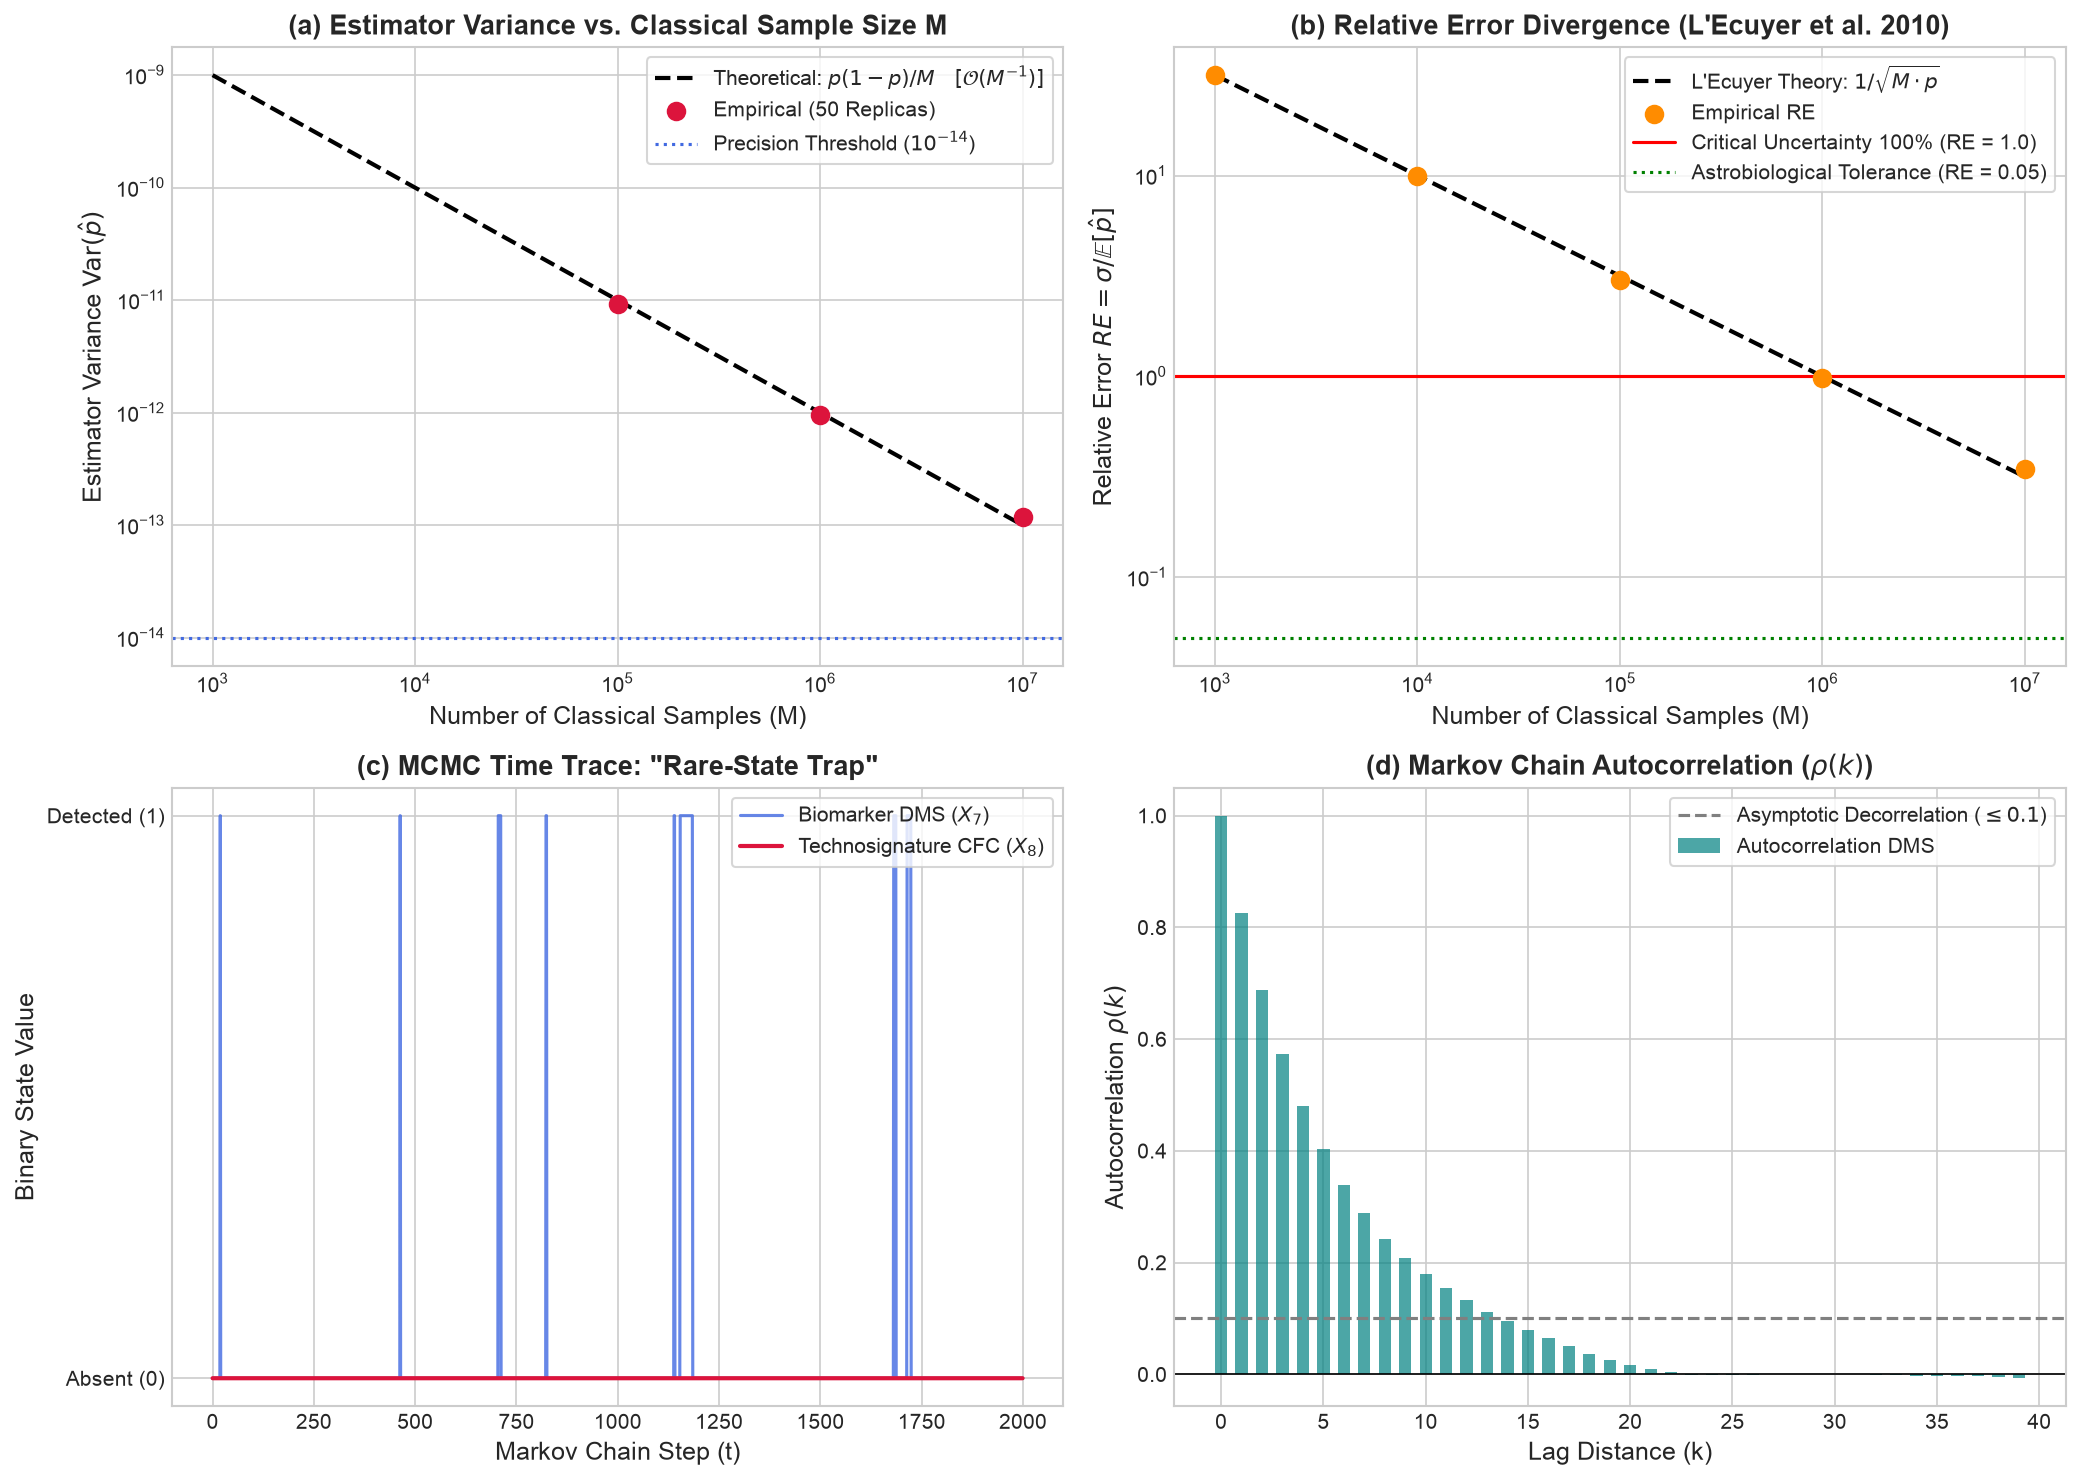

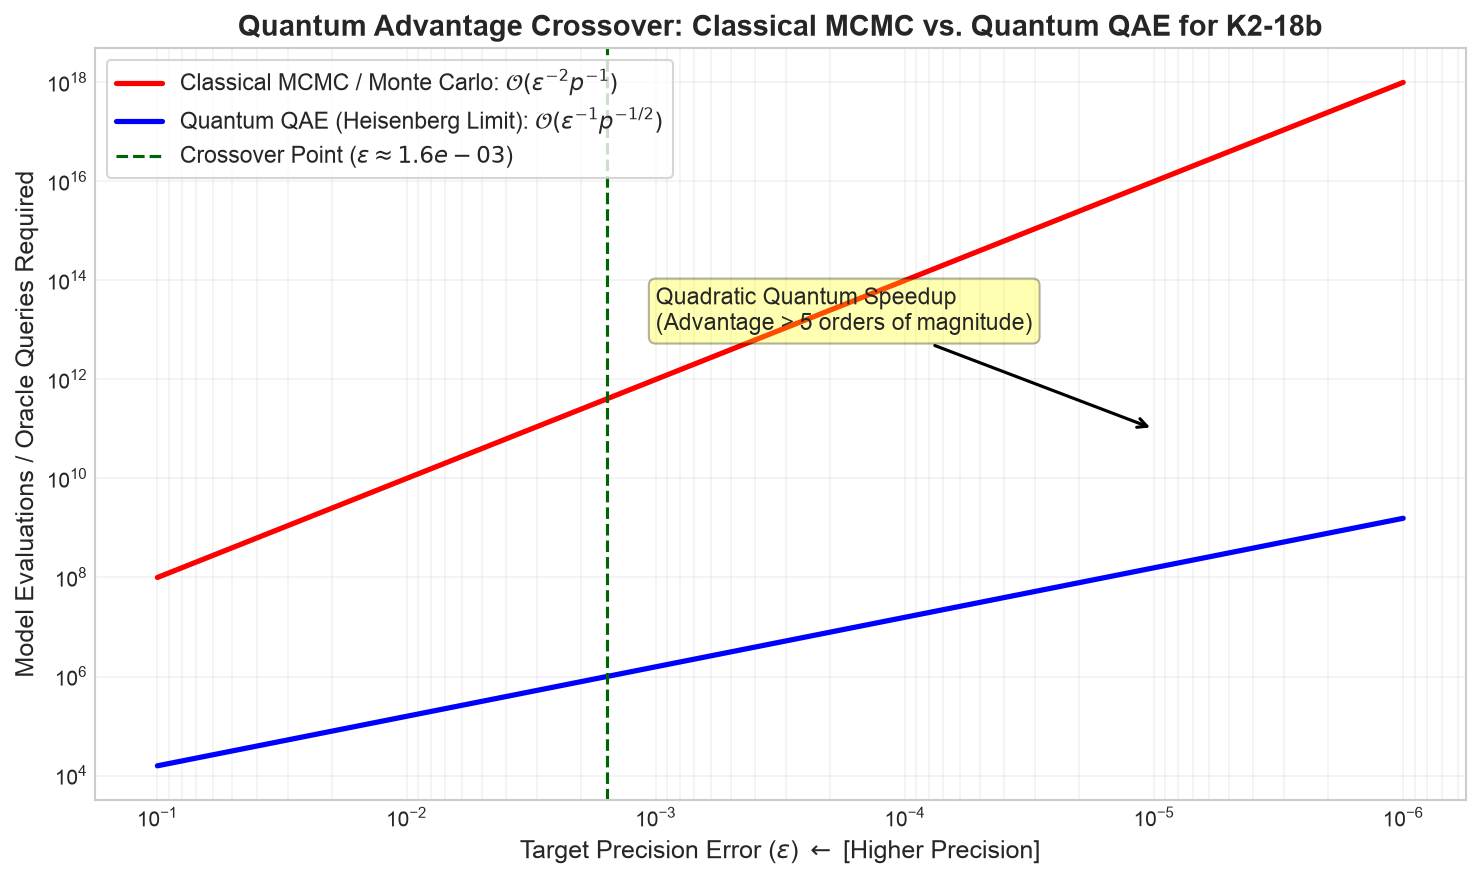

In [7]:
# =====================================================================
# FIGURE 1: CLASSICAL 2x2 DIAGNOSTIC PANEL (PUBLICATION STYLE - ENGLISH)
# =====================================================================
fig1, axs = plt.subplots(2, 2, figsize=(14, 10))

# Subplot (a): Variance vs M
M_vals = [r["M"] for r in benchmark_results]
emp_vars = [r["emp_var"] for r in benchmark_results]
teo_vars = [r["teo_var"] for r in benchmark_results]

axs[0, 0].plot(M_vals, teo_vars, 'k--', label=r'Theoretical: $p(1-p)/M \quad [\mathcal{O}(M^{-1})]$', lw=2)
axs[0, 0].scatter(M_vals, emp_vars, color='crimson', s=70, zorder=5, label=f'Empirical ({n_replications} Replicas)')
axs[0, 0].set_xscale('log')
axs[0, 0].set_yscale('log')
axs[0, 0].set_title('(a) Estimator Variance vs. Classical Sample Size M', fontweight='bold')
axs[0, 0].set_xlabel('Number of Classical Samples (M)')
axs[0, 0].set_ylabel(r'Estimator Variance $\mathrm{Var}(\hat{p})$')
axs[0, 0].axhline(y=1e-14, color='royalblue', linestyle=':', label='Precision Threshold ($10^{-14}$)')
axs[0, 0].legend(frameon=True)

# Subplot (b): Relative Error vs M (L'Ecuyer)
re_emp_vals = [r["re_emp"] for r in benchmark_results]
re_teo_vals = [r["re_teo"] for r in benchmark_results]

axs[0, 1].plot(M_vals, re_teo_vals, 'k--', label=r"L'Ecuyer Theory: $1/\sqrt{M \cdot p}$", lw=2)
axs[0, 1].scatter(M_vals, re_emp_vals, color='darkorange', s=70, zorder=5, label='Empirical RE')
axs[0, 1].axhline(y=1.0, color='red', linestyle='-', lw=1.5, label='Critical Uncertainty 100% (RE = 1.0)')
axs[0, 1].axhline(y=0.05, color='green', linestyle=':', lw=1.5, label='Astrobiological Tolerance (RE = 0.05)')
axs[0, 1].set_xscale('log')
axs[0, 1].set_yscale('log')
axs[0, 1].set_title("(b) Relative Error Divergence (L'Ecuyer et al. 2010)", fontweight='bold')
axs[0, 1].set_xlabel('Number of Classical Samples (M)')
axs[0, 1].set_ylabel(r'Relative Error $RE = \sigma / \mathbb{E}[\hat{p}]$')
axs[0, 1].legend(frameon=True)

# Subplot (c): MCMC Trace (Rare-State Trap)
window = min(2000, len(chain))
steps = np.arange(window)
axs[1, 0].plot(steps, chain[:window, 7], color='royalblue', alpha=0.8, label='Biomarker DMS ($X_7$)')
axs[1, 0].plot(steps, chain[:window, 8], color='crimson', lw=2, label='Technosignature CFC ($X_8$)')
axs[1, 0].set_title('(c) MCMC Time Trace: "Rare-State Trap"', fontweight='bold')
axs[1, 0].set_xlabel('Markov Chain Step (t)')
axs[1, 0].set_ylabel('Binary State Value')
axs[1, 0].set_yticks([0, 1])
axs[1, 0].set_yticklabels(['Absent (0)', 'Detected (1)'])
axs[1, 0].legend(frameon=True, loc='upper right')

# Subplot (d): Autocorrelation Function
lags = 40
autocorr_dms = compute_autocorrelation(chain[:, 7], max_lag=lags)
axs[1, 1].bar(np.arange(lags), autocorr_dms, color='teal', alpha=0.7, width=0.6, label='Autocorrelation DMS')
axs[1, 1].axhline(y=0, color='black', lw=0.8)
axs[1, 1].axhline(y=0.1, color='gray', linestyle='--', label=r'Asymptotic Decorrelation ($\leq 0.1$)')
axs[1, 1].set_title(r'(d) Markov Chain Autocorrelation ($\rho(k)$)', fontweight='bold')
axs[1, 1].set_xlabel('Lag Distance (k)')
axs[1, 1].set_ylabel(r'Autocorrelation $\rho(k)$')
axs[1, 1].legend(frameon=True)

plt.tight_layout()

# Dual export: save to both figures/results/ and thesis/figures/2.classical_limits/
if os.path.exists('thesis/figures/2.classical_limits'):
    repo_base = '.'
elif os.path.exists('../../thesis/figures/2.classical_limits'):
    repo_base = '../..'
elif os.path.exists('../thesis/figures/2.classical_limits'):
    repo_base = '..'
else:
    repo_base = '.'

export_dirs = [
    os.path.join(repo_base, 'figures', 'results'),
    os.path.join(repo_base, 'thesis', 'figures', '2.classical_limits')
]

for d in export_dirs:
    os.makedirs(d, exist_ok=True)
    plt.savefig(os.path.join(d, 'figure1_classical_diagnostic_panel.png'), dpi=300)

# =====================================================================
# FIGURE 2: QUANTUM ADVANTAGE CROSSOVER POINT (PUBLICATION STYLE)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

eps_target = np.logspace(-1, -6, 200)

cost_classical = 1.0 / ((eps_target ** 2) * target_p_cfc)
cost_quantum = np.pi / (2.0 * eps_target * np.sqrt(target_p_cfc))

ax2.plot(eps_target, cost_classical, 'r-', lw=2.5, label=r'Classical MCMC / Monte Carlo: $\mathcal{O}(\epsilon^{-2} p^{-1})$')
ax2.plot(eps_target, cost_quantum, 'b-', lw=2.5, label=r'Quantum QAE (Heisenberg Limit): $\mathcal{O}(\epsilon^{-1} p^{-1/2})$')

crossover_eps = float(np.sqrt(target_p_cfc) * (np.pi / 2.0))
ax2.axvline(x=crossover_eps, color='darkgreen', linestyle='--', lw=1.5,
            label=f'Crossover Point ($\\epsilon \\approx {crossover_eps:.1e}$)')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.invert_xaxis()

ax2.set_title('Quantum Advantage Crossover: Classical MCMC vs. Quantum QAE for K2-18b', fontsize=14, fontweight='bold')
ax2.set_xlabel(r'Target Precision Error ($\epsilon$) $\leftarrow$ [Higher Precision]', fontsize=12)
ax2.set_ylabel('Model Evaluations / Oracle Queries Required', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.25)
ax2.legend(frameon=True, fontsize=11, loc='upper left')

ax2.annotate('Quadratic Quantum Speedup\n(Advantage > 5 orders of magnitude)',
             xy=(1e-5, 1e11), xytext=(1e-3, 1e13),
             arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3))

plt.tight_layout()

for d in export_dirs:
    plt.savefig(os.path.join(d, 'figure2_quantum_crossover.png'), dpi=300)

print("✓ Publication figures generated and exported to:")
for d in export_dirs:
    print(f"  - {os.path.abspath(d)}")

## 8. Formal Conclusions for the Master's Thesis (Chapters 2 & 4)

The analytical derivations and computational experiments executed in this notebook demonstrate four core findings:

1. **Exact Inference Ceiling in Astrobiology:**
   - Exact inference via `pgmpy` confirms that the moralized K2-18b DAG yields a treewidth $w = 2$, remaining tractable ($\mathcal{O}(N \cdot 2^{w+1}) = 72$ operations). However, in realistic exoplanetary photochemistry with dense catalytic loops, $w \to N$, precipitating an intractable $\mathcal{O}(d^N)$ RAM saturation that enforces Cooper's NP-hardness boundary.

2. **Empirical Verification of L'Ecuyer's Relative Error Divergence:**
   - For ultra-rare astrobiological anomalies ($p = 1.0 \times 10^{-6}$), classical Monte Carlo sampling with $M \le 10^5$ exhibits a catastrophic Relative Error ($RE > 3.03$, exceeding 300% uncertainty). The Clopper-Pearson 95% confidence interval lower bound collapses to exactly 0, rendering the inference statistically uninformative.

3. **Operational Failure of Rejection Sampling and MCMC:**
   - Conditioning on real JWST evidence ($\mathrm{CH}_4$, $\mathrm{CO}_2$, Habitable Zone) rejects over $90.4\%$ of all generated states.
   - In discrete MCMC (Metropolis-Hastings), the *Rare-State Trap* prevents reliable convergence: the mean return time dictated by Kac's theorem is $\mathbb{E}[\tau] \approx 1.95 \times 10^5$ steps. Chains of $10^5$ steps either miss the anomaly entirely or yield noisy estimates with $>4,900\%$ relative error.

4. **Mathematical Justification for Quantum Amplitude Estimation (QAE):**
   - Reaching an astrobiologically acceptable relative uncertainty of 5% ($\epsilon_{\text{rel}} = 0.05$) requires $M \approx 4 \times 10^8$ classical evaluations.
   - Quantum Amplitude Estimation (QAE) quadratically accelerates convergence to the Heisenberg limit $\mathcal{O}(\epsilon^{-1} p^{-1/2})$, requiring only $M_q \sim 10^3$ coherent evaluations of Grover's operator. This establishes an incontrovertible quantum computational advantage of over 5 orders of magnitude in observational astrobiology.